In [1]:
# Note: Install both `./requirements.txt` and `./examples/requirements.txt` to run this notebook
RANDOM_SEED = 42

In [2]:
# dataset
import pandas as pd
data = pd.read_csv("./_datasets/iris.data", header=None, index_col=None)
iris = data.iloc[:, :-1]
iris_target = data.iloc[:, -1]
X = iris.values
y = iris_target.values

In [3]:
# encode labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)
label_decoder = {i: label for i, label in enumerate(le.classes_)}

In [4]:
# scale data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
del X

In [5]:
# SOM embedding
from minisom import MiniSom

def train_som(X, d1, d2, sigma, topology, learning_rate, num_iteration, decay_function, sigma_decay_function, use_epochs, random_order, random_seed=None, verb=True):
	som = MiniSom(d1, d2, input_len=X.shape[1], sigma=sigma, learning_rate=learning_rate, topology=topology, decay_function=decay_function, sigma_decay_function=sigma_decay_function, random_seed=random_seed)
	som.random_weights_init(X)
	som.train(X, num_iteration=num_iteration, random_order=random_order, use_epochs=use_epochs, verbose=verb)
	return som

hyperparams = {
    "d1": 6,
    "d2": 11,
    "sigma": 3.67,
	"topology": "rectangular",
	"learning_rate": 0.6,
	"num_iteration": 17,
	"decay_function": "linear_decay_to_zero",
	"sigma_decay_function": "asymptotic_decay",
	"use_epochs": True,
	"random_order": True,
	"random_seed": RANDOM_SEED,
	"verb": True,
}

som = train_som(X_scaled, **hyperparams)
print(" topographic error: ", som.topographic_error(X_scaled))

 [ 2550 / 2550 ] 100% - 0:00:00 left 
 quantization error: 0.438505958743615
 topographic error:  0.0


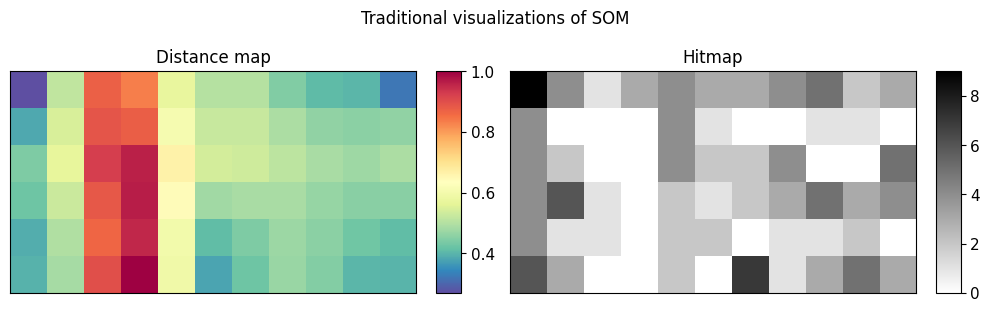

In [6]:
# conventional SOM visualization
from lilypond.basin import Basin
basin = Basin(som, X_scaled, random_seed=RANDOM_SEED).prepare()
basin.legacy_pond().visualize(figsize=(10, 3.25));

/var/folders/_8/wrnf3yvs3jg52zw_72p2w64w0000gn/T/ipykernel_52691/2875018682.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('spring_r')


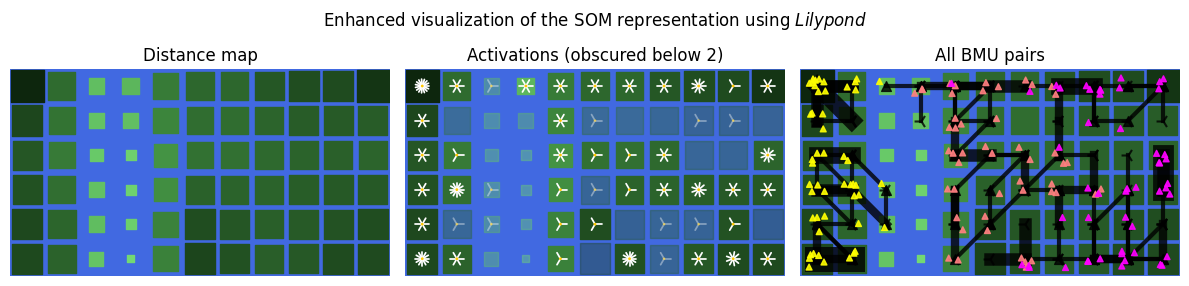

In [7]:
# lilypond visualization

import matplotlib.pyplot as plt
import numpy as np

coloring_strategy = "distance_map"
flood_below_activations = 2

pad_style = {
    "marker": "s",
	"gap": -.055,
}

petal_style = {
	"magnifier": 3,
	"width": 1.25,
	"size_base": .4,
}

figsize = (12, 3)
fig, axes = plt.subplots(1, 3, figsize=figsize)

ax = axes[0]
basin.pond() \
    .set_coloring_strategy(coloring_strategy) \
    .flood(below_activations=0) \
	.style_pad(**pad_style) \
	.style_petal(hide=True) \
	.observe(return_fig=True, ax=ax, title="Distance map")

ax = axes[1]
basin.pond() \
    .set_coloring_strategy(coloring_strategy) \
    .flood(below_activations=flood_below_activations) \
	.discretize_petals(n_bins=5) \
	.style_pad(**pad_style) \
	.style_petal(**petal_style) \
	.observe(return_fig=True, ax=ax, title=f"Activations (obscured below {flood_below_activations})")

rhizome_style = {
    "zorder": 11,
	"marker_start": "^",
	"marker_end": "3",
	"opacity": .8,
	"linewidth": 3,
}

from matplotlib.colors import ListedColormap
num_unique_y = len(np.unique(y_encoded))
cmap = plt.cm.get_cmap('spring_r')
colors = cmap(np.linspace(0, 1, num_unique_y))
cmap = ListedColormap(colors)

attract_style = {
    "cmap": cmap,
    "cmap_values": y_encoded,
    "cmap_label": "Class",
    "label": "Iris",
    "zorder": 21,
    "marker": "^",
    "size_base": 18,
    "opacity": .9,
    "subsample_ratio": None,
}

ax = axes[2]
basin.pond() \
    .set_coloring_strategy(coloring_strategy) \
    .flood(below_activations=0) \
	.style_pad(**pad_style) \
	.style_petal(hide=True) \
	.style_rhizome(**rhizome_style) \
	.see_rhizome(mode="all", ax=ax) \
	.attract(X_scaled, **attract_style) \
	.observe(return_fig=True, ax=ax, title="All BMU pairs")

for ax in axes:
	ax.set_aspect('equal')
	ax.axis("off")

all_axes = fig.get_axes()
colorbar_axis = all_axes[-1]
colorbar_axis.remove()

plt.suptitle("Enhanced visualization of the SOM representation using $Lilypond$")
plt.tight_layout()
plt.show()